# MNIST Digit Classification using ANN


## Step 1: Import Libraries

We import the tools needed for:
- data handling (NumPy)
- visualization (Matplotlib, Seaborn)
- building the neural network (TensorFlow/Keras)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

## Step 2: Load Dataset

We load the MNIST dataset, which contains:
- 60,000 training images
- 10,000 testing images

Each image is 28×28 pixels.

In [15]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [16]:
# Check shape
print(X_train.shape)  # (60000, 28, 28)

(60000, 28, 28)


## Step 3: Visualize Sample Images

We display a few images to understand the dataset.
Each image represents a handwritten digit (0–9).

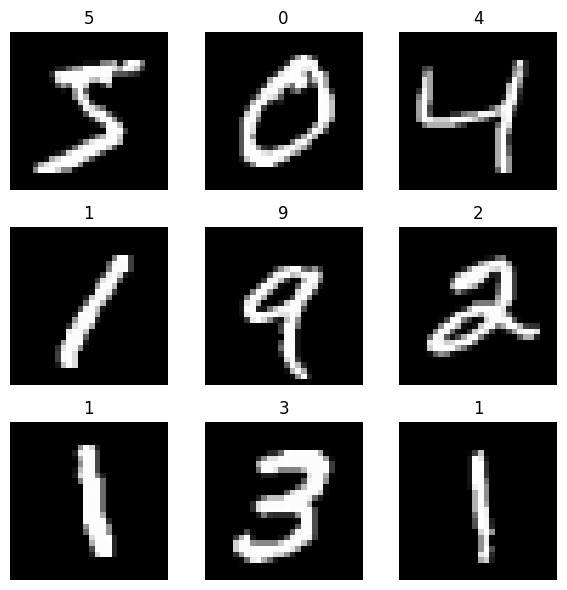

In [26]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 4: Preprocess Data

Before training, we prepare the data:

- Normalize pixel values (0–255 → 0–1)
- Helps the model learn faster
- Convert labels using one-hot encoding

In [27]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [28]:
# Confurm Data shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)
y_train: (60000, 10)
y_test: (10000, 10)


## Step 5: Build the Model

We create an Artificial Neural Network:

- Flatten → converts image to 1D
- Dense layers → learn patterns
- Dropout → reduces overfitting
- Output → predicts digits (0–9)

In [29]:
model = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

## Step 6: Compile Model

We define how the model learns:

- Loss function: categorical crossentropy
- Optimizer: Adam
- Metric: accuracy

In [20]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Step 7: Train Model

We train the model using the training data over multiple epochs.

In [34]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Changed to categorical_crossentropy for one-hot encoded labels
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5029 - loss: 1.5262 - val_accuracy: 0.8135 - val_loss: 0.7185
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7598 - loss: 0.7512 - val_accuracy: 0.8803 - val_loss: 0.4543
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8210 - loss: 0.5808 - val_accuracy: 0.8975 - val_loss: 0.3671
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8500 - loss: 0.4981 - val_accuracy: 0.9138 - val_loss: 0.3086
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8688 - loss: 0.4435 - val_accuracy: 0.9223 - val_loss: 0.2721
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8826 - loss: 0.4007 - val_accuracy: 0.9295 - val_loss: 0.2470
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8923 - loss: 0.3692 - val_accuracy: 0.9362 - val_loss: 0.2235
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9005 - loss: 0.3427 - val_accuracy: 0

## Step 8: Evaluate Model

We test the model on unseen data to measure performance.

Main metric: accuracy

In [35]:
# Evaluate performance
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9327 - loss: 0.2175
Accuracy: 0.9327


## Step 9: Make Predictions

The model predicts digits from test images.

We compare predictions with actual labels to check correctness.

In [36]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Confusion Matrix


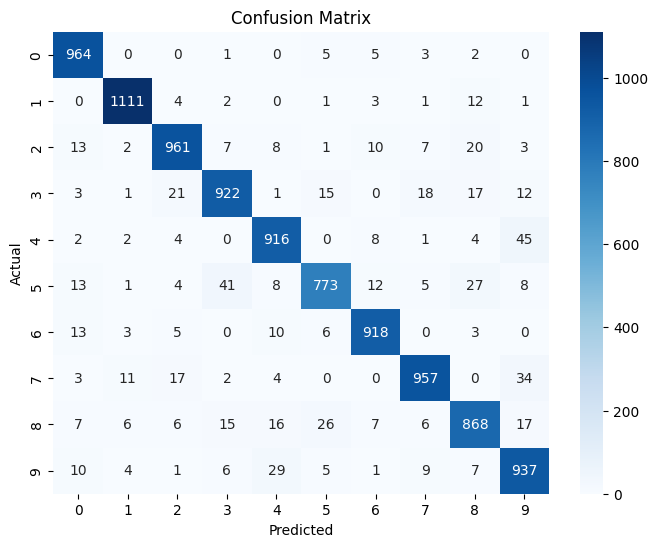

In [37]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification report

In [38]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.98      0.98      1135
           2       0.94      0.93      0.94      1032
           3       0.93      0.91      0.92      1010
           4       0.92      0.93      0.93       982
           5       0.93      0.87      0.90       892
           6       0.95      0.96      0.96       958
           7       0.95      0.93      0.94      1028
           8       0.90      0.89      0.90       974
           9       0.89      0.93      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



## Conclusion

- The ANN successfully classifies handwritten digits
- Performance depends on model design and training
- Can be improved with deeper networks or CNNs

Save Model


In [39]:
model.save("mnist_ann_model.keras")